# Phân rã theo thời gian — model fail ở đâu

> Dùng **Conformal chuẩn hoá** (phương pháp đang chọn). Xem `01_conformal_chuan_hoa` để hiểu
> cách dựng khoảng.

Tách riêng khỏi notebook phương pháp vì đây là **câu trả lời trực tiếp cho ý 2 và ý 3** trong
feedback tuần 3 của mentor, cần trình bày độc lập.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 13, "axes.labelsize": 11.5,
    "xtick.labelsize": 10.5, "ytick.labelsize": 10.5, "legend.fontsize": 10.5,
})
EVAL = Path("../evaluation")
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

MUC = 0.90
CAO_DIEM = [(7, 9), (17, 19)]

uc = pd.read_parquet(EVAL / "uq_pred_calibration.parquet")
ut = pd.read_parquet(EVAL / "uq_pred_test.parquet")
q90 = np.quantile(((uc.hybrid_pred - uc.gia_that).abs() / uc.hybrid_pred).values, MUC)

t = ut.copy()
t["mua"] = t.weather_main.isin(["Rain", "Drizzle", "Thunderstorm"])
t["lo"] = t.hybrid_pred * (1 - q90)
t["hi"] = t.hybrid_pred * (1 + q90)
t["trong"] = (t.gia_that >= t.lo) & (t.gia_that <= t.hi)
t["sai_rel"] = (t.hybrid_pred - t.gia_that).abs() / t.gia_that
t["ngay"] = t.target_timestamp.dt.date
t["cao_diem"] = t.gio_vn.apply(lambda h: any(a <= h <= b for a, b in CAO_DIEM))

# Khong che quang duong 4-6km: bo bien thien do do dai chuyen,
# chi con dao dong do GIO va CUNG-CAU — dung thu can danh gia
band = t[(t.quote_distance >= 4) & (t.quote_distance <= 6)].copy()

print(f"Tap test  : {len(t):,} chuyen · {t.ngay.nunique()} ngay")
print(f"Dai 4–6km : {len(band):,} chuyen ({len(band)/len(t):.0%})")
print(f"q 90%     : ±{q90:.2%}")
print()
print("So chuyen 4-6km tung ngay:")
for d_, n in band.groupby("ngay").size().items():
    n_mua = band[(band.ngay == d_) & band.mua].shape[0]
    print(f"  {d_}  {n:>7,}  ({n_mua/n:>5.1%} mua)")

Tap test  : 864,360 chuyen · 11 ngay
Dai 4–6km : 330,288 chuyen (38%)
q 90%     : ±30.09%

So chuyen 4-6km tung ngay:
  2026-01-28   30,192  (45.3% mua)
  2026-01-29   29,400  (34.0% mua)
  2026-01-30   30,944  (46.8% mua)
  2026-01-31   30,204  (45.9% mua)
  2026-02-26   29,984  (49.2% mua)
  2026-02-27   29,764  (31.4% mua)
  2026-02-28   30,348  (45.4% mua)
  2026-03-27   30,436  (49.8% mua)
  2026-03-28   30,564  (41.2% mua)
  2026-03-29   29,384  (38.7% mua)
  2026-03-30   29,068  (58.6% mua)


## 1. Chuỗi thời gian — thật vs dự đoán, có dải UQ và chú thích

Chọn ngày có **biến động thời tiết rõ nhất** để hình có thông tin. Gộp theo 30 phút, khống chế
cùng dải quãng đường **4–6 km** để loại bỏ nhiễu do độ dài chuyến.

Ngay duoc chon: 2026-03-27  (ty le mua 50%)


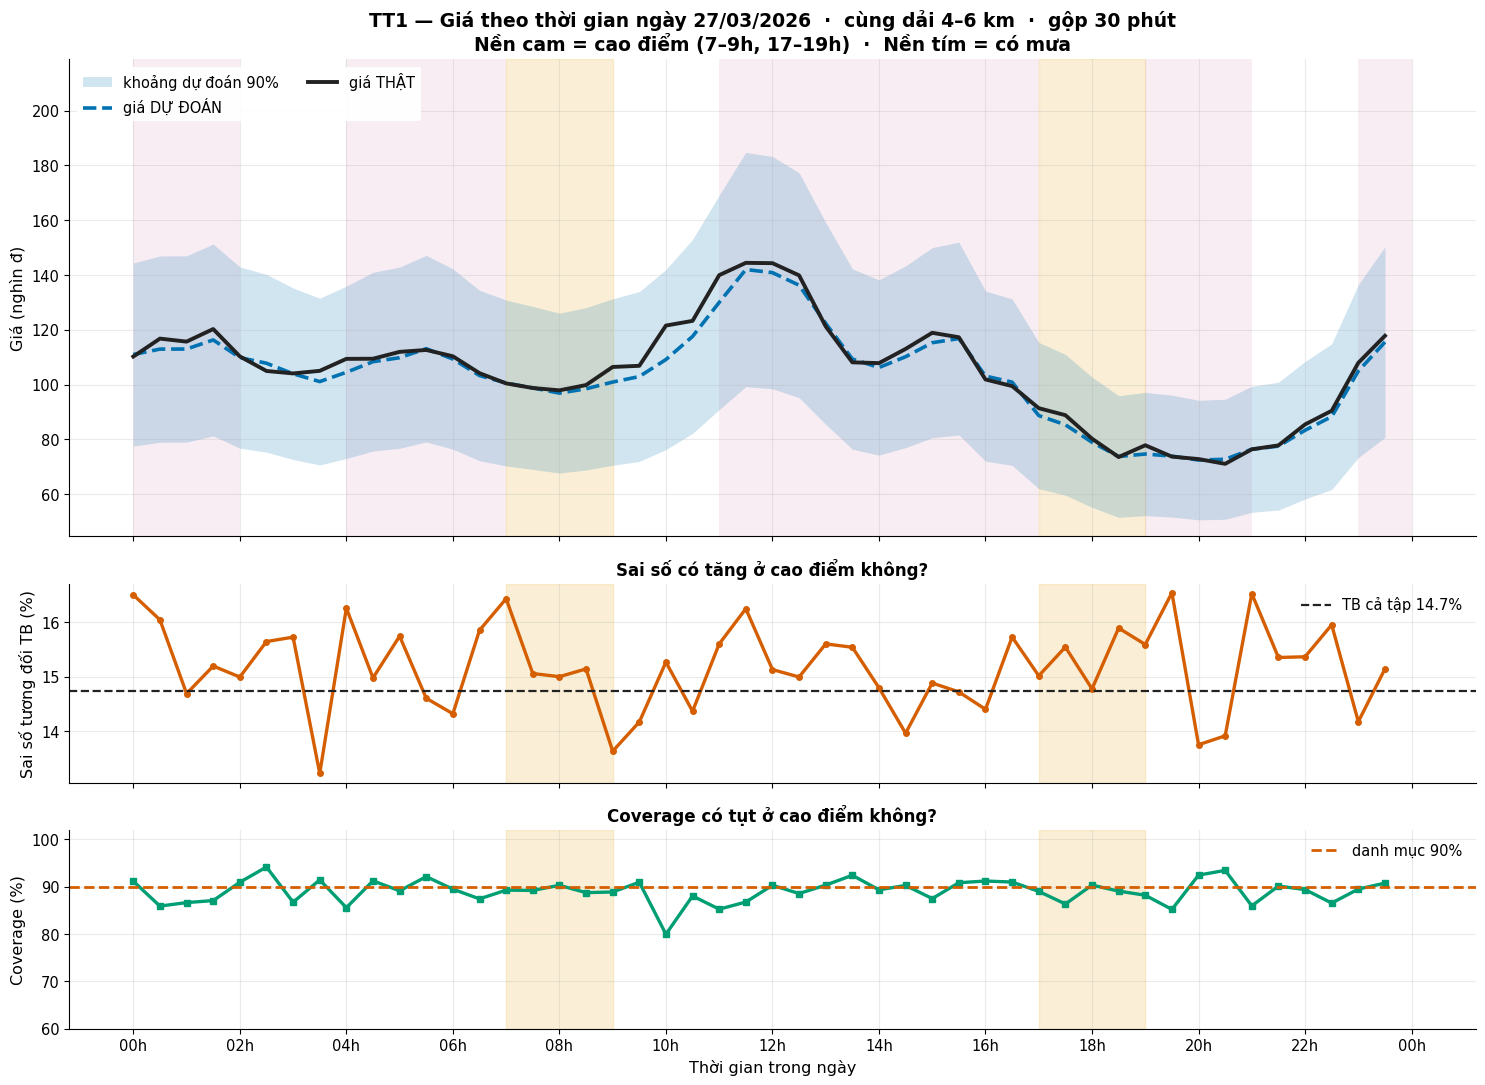


Ngay 2026-03-27:
  Cao diem   : sai so 15.24% | coverage 88.80%
  Gio thuong : sai so 15.15% | coverage 89.15%


In [2]:
# ═════════ HINH TT1 — chuoi thoi gian co chu thich ═════════
# Chon ngay co ty le mua gan 50% nhat -> nhieu tuong phan nhat
ty_mua = band.groupby("ngay").mua.mean()
NGAY = (ty_mua - .5).abs().idxmin()
print(f"Ngay duoc chon: {NGAY}  (ty le mua {ty_mua[NGAY]:.0%})")

d = band[band.ngay == NGAY].copy()
d["buc"] = d.target_timestamp.dt.floor("30min")
g = d.groupby("buc").agg(
    that=("gia_that", "mean"), pred=("hybrid_pred", "mean"),
    lo=("lo", "mean"), hi=("hi", "mean"),
    cvg=("trong", "mean"), sai=("sai_rel", "mean"),
    mua=("mua", "mean"), heso=("heso_that", "mean"), n=("gia_that", "size"))
g = g[g.n >= 50]

fig, ax = plt.subplots(3, 1, figsize=(15, 11), sharex=True,
                       gridspec_kw={"height_ratios": [2.4, 1, 1]})

# ── Panel 1: gia ──
a = ax[0]
for h1, h2 in CAO_DIEM:
    a.axvspan(pd.Timestamp(NGAY) + pd.Timedelta(hours=h1),
              pd.Timestamp(NGAY) + pd.Timedelta(hours=h2),
              color=ORANGE, alpha=.16, zorder=0)
# danh dau khoang mua
mua_buc = g.index[g.mua > .5]
for b_ in mua_buc:
    a.axvspan(b_, b_ + pd.Timedelta(minutes=30), color=PURPLE, alpha=.13, lw=0, zorder=0)

a.fill_between(g.index, g.lo/1000, g.hi/1000, color=BLUE, alpha=.18, lw=0,
               label=f"khoảng dự đoán {MUC:.0%}")
a.plot(g.index, g.pred/1000, lw=2.6, color=BLUE, ls="--", label="giá DỰ ĐOÁN")
a.plot(g.index, g.that/1000, lw=2.8, color=INK, label="giá THẬT")
ngoai = g[(g.that < g.lo) | (g.that > g.hi)]
if len(ngoai):
    a.plot(ngoai.index, ngoai.that/1000, "o", color=RED, ms=9, zorder=5,
           label="trung bình bucket rơi NGOÀI khoảng")
a.set_ylabel("Giá (nghìn đ)")
# nới trần để chú thích không đè lên dải, nới đáy để không cắt cận dưới
a.set_ylim(g.lo.min()/1000 - 6, g.hi.max()/1000 + 34)
a.legend(frameon=True, framealpha=.95, edgecolor="none", loc="upper left", ncol=2)
a.set_title(f"TT1 — Giá theo thời gian ngày {NGAY:%d/%m/%Y}  ·  cùng dải 4–6 km  ·  gộp 30 phút\n"
            "Nền cam = cao điểm (7–9h, 17–19h)  ·  Nền tím = có mưa",
            fontweight="bold", fontsize=13.5)

# ── Panel 2: sai so tuong doi ──
b = ax[1]
for h1, h2 in CAO_DIEM:
    b.axvspan(pd.Timestamp(NGAY) + pd.Timedelta(hours=h1),
              pd.Timestamp(NGAY) + pd.Timedelta(hours=h2),
              color=ORANGE, alpha=.16, zorder=0)
b.plot(g.index, g.sai*100, lw=2.4, color=RED, marker="o", ms=4)
b.axhline(t.sai_rel.mean()*100, color=INK, lw=1.6, ls="--",
          label=f"TB cả tập {t.sai_rel.mean():.1%}")
b.set_ylabel("Sai số tương đối TB (%)")
b.legend(frameon=False)
b.set_title("Sai số có tăng ở cao điểm không?", fontweight="bold", fontsize=12)

# ── Panel 3: coverage ──
c = ax[2]
for h1, h2 in CAO_DIEM:
    c.axvspan(pd.Timestamp(NGAY) + pd.Timedelta(hours=h1),
              pd.Timestamp(NGAY) + pd.Timedelta(hours=h2),
              color=ORANGE, alpha=.16, zorder=0)
c.plot(g.index, g["cvg"]*100, lw=2.4, color=GREEN, marker="s", ms=4)
c.axhline(MUC*100, color=RED, lw=2, ls="--", label="danh mục 90%")
c.set_ylabel("Coverage (%)"); c.set_ylim(60, 102)
c.set_xlabel("Thời gian trong ngày")
c.legend(frameon=False)
c.set_title("Coverage có tụt ở cao điểm không?", fontweight="bold", fontsize=12)

for a_ in ax:
    a_.xaxis.set_major_formatter(mdates.DateFormatter("%Hh"))
    a_.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.tight_layout(); plt.savefig(HINH / "TT1_chuoi_thoi_gian.png"); plt.show()

cd = g[[any(pd.Timestamp(i).hour in range(h1, h2+1) for h1, h2 in CAO_DIEM)
        for i in g.index]]
kh = g[[not any(pd.Timestamp(i).hour in range(h1, h2+1) for h1, h2 in CAO_DIEM)
        for i in g.index]]
cov_cd, cov_kh = cd["cvg"].mean(), kh["cvg"].mean()
print(f"\nNgay {NGAY}:")
print(f"  Cao diem   : sai so {cd.sai.mean():.2%} | coverage {cov_cd:.2%}")
print(f"  Gio thuong : sai so {kh.sai.mean():.2%} | coverage {cov_kh:.2%}")

## 2. Sai số theo từng giờ — trên toàn bộ tập test

Một ngày có thể là ngoại lệ. Phần này gộp cả **11 ngày** để xem quy luật.

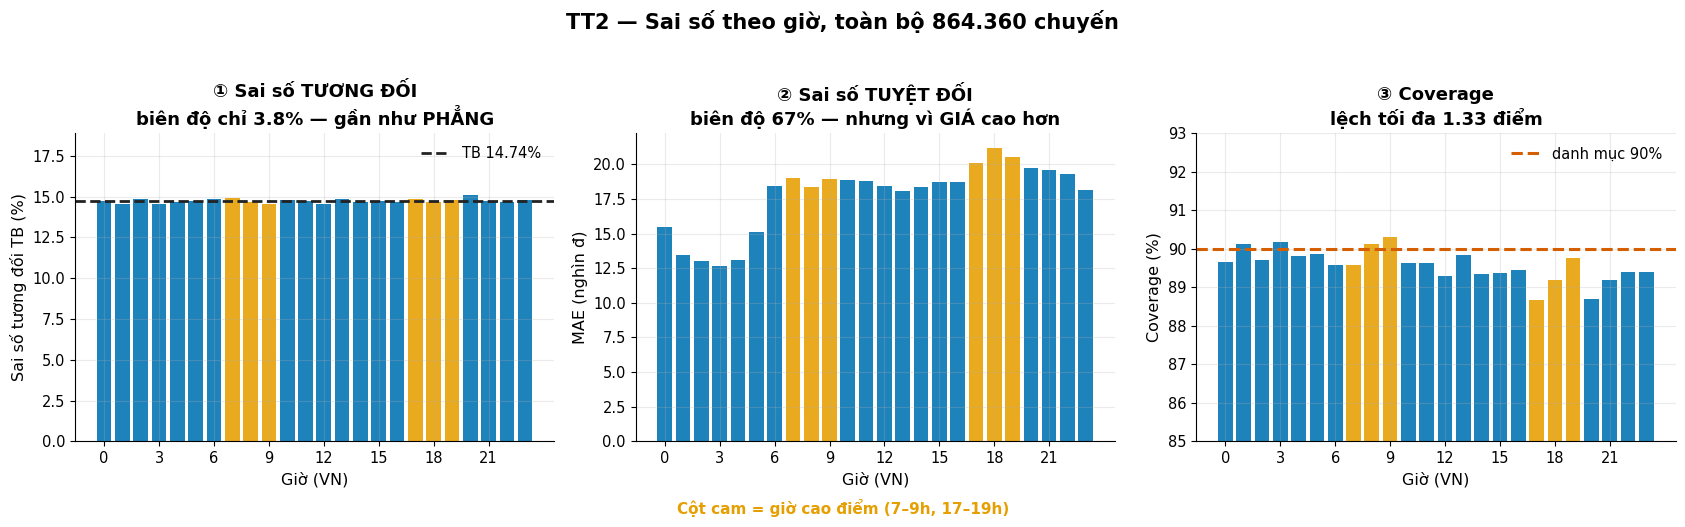

                          n        MAE   sai so rel   coverage
--------------------------------------------------------------
  Cao diem          229,820    19,703d      14.74%     89.61%
  Gio thuong        634,540    17,449d      14.75%     89.53%


In [3]:
# ═════════ HINH TT2 — sai so theo gio ═════════
gh = t.groupby("gio_vn").agg(
    n=("gia_that", "size"), sai=("sai_rel", "mean"),
    cvg=("trong", "mean"), gia=("gia_that", "mean"),
    rong=("hi", "mean"))
gh["rong"] = (t.groupby("gio_vn").hi.mean() - t.groupby("gio_vn").lo.mean())
gh["mae"] = t.groupby("gio_vn").apply(
    lambda x: np.abs(x.hybrid_pred - x.gia_that).mean())

fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
mau_gio = [ORANGE if any(a <= h <= b for a, b in CAO_DIEM) else BLUE
           for h in gh.index]

# ① MAPE theo gio
ax[0].bar(gh.index, gh.sai*100, color=mau_gio, alpha=.88)
ax[0].axhline(t.sai_rel.mean()*100, color=INK, lw=2, ls="--",
              label=f"TB {t.sai_rel.mean():.2%}")
ax[0].set_xticks(range(0, 24, 3)); ax[0].set_xlabel("Giờ (VN)")
ax[0].set_ylabel("Sai số tương đối TB (%)")
ax[0].set_ylim(0, gh.sai.max()*100*1.25)
ax[0].legend(frameon=False)
bd = (gh.sai.max()/gh.sai.min()-1)*100
ax[0].set_title(f"① Sai số TƯƠNG ĐỐI\nbiên độ chỉ {bd:.1f}% — gần như PHẲNG",
                fontweight="bold")

# ② MAE tuyet doi
ax[1].bar(gh.index, gh.mae/1000, color=mau_gio, alpha=.88)
ax[1].set_xticks(range(0, 24, 3)); ax[1].set_xlabel("Giờ (VN)")
ax[1].set_ylabel("MAE (nghìn đ)")
bd2 = (gh.mae.max()/gh.mae.min()-1)*100
ax[1].set_title(f"② Sai số TUYỆT ĐỐI\nbiên độ {bd2:.0f}% — nhưng vì GIÁ cao hơn",
                fontweight="bold")

# ③ Coverage
ax[2].bar(gh.index, gh["cvg"]*100, color=mau_gio, alpha=.88)
ax[2].axhline(MUC*100, color=RED, lw=2.2, ls="--", label="danh mục 90%")
ax[2].set_xticks(range(0, 24, 3)); ax[2].set_xlabel("Giờ (VN)")
ax[2].set_ylabel("Coverage (%)"); ax[2].set_ylim(85, 93)
ax[2].legend(frameon=False)
lech_gio = abs(gh["cvg"]*100 - 90).max()
ax[2].set_title(f"③ Coverage\nlệch tối đa {lech_gio:.2f} điểm",
                fontweight="bold")

fig.text(.5, -.02, "Cột cam = giờ cao điểm (7–9h, 17–19h)", ha="center",
         fontsize=11, color=ORANGE, fontweight="bold")
fig.suptitle("TT2 — Sai số theo giờ, toàn bộ 864.360 chuyến",
             fontweight="bold", fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "TT2_sai_so_theo_gio.png"); plt.show()

print(f"{'':16s} {'n':>10s} {'MAE':>10s} {'sai so rel':>12s} {'coverage':>10s}")
print("-" * 62)
for ten, m in [("Cao diem", t.cao_diem), ("Gio thuong", ~t.cao_diem)]:
    s = t[m]
    print(f"  {ten:14s} {len(s):>10,} {np.abs(s.hybrid_pred-s.gia_that).mean():>9,.0f}d "
          f"{s.sai_rel.mean():>11.2%} {s.trong.mean():>10.2%}")

## 3. Các đợt **demand surge** — đo riêng

Cao điểm theo giờ là một chuyện; **demand surge thật** là chuyện khác — nó xảy ra bất kỳ lúc nào
khi cung–cầu mất cân bằng. Phần này tìm các đợt surge trong dữ liệu và đo sai số riêng.

**Cách xác định:** gộp theo 30 phút trên toàn bộ 11 ngày, đánh dấu bucket có **hệ số nhân trung
bình thuộc top 10%** là đợt surge.

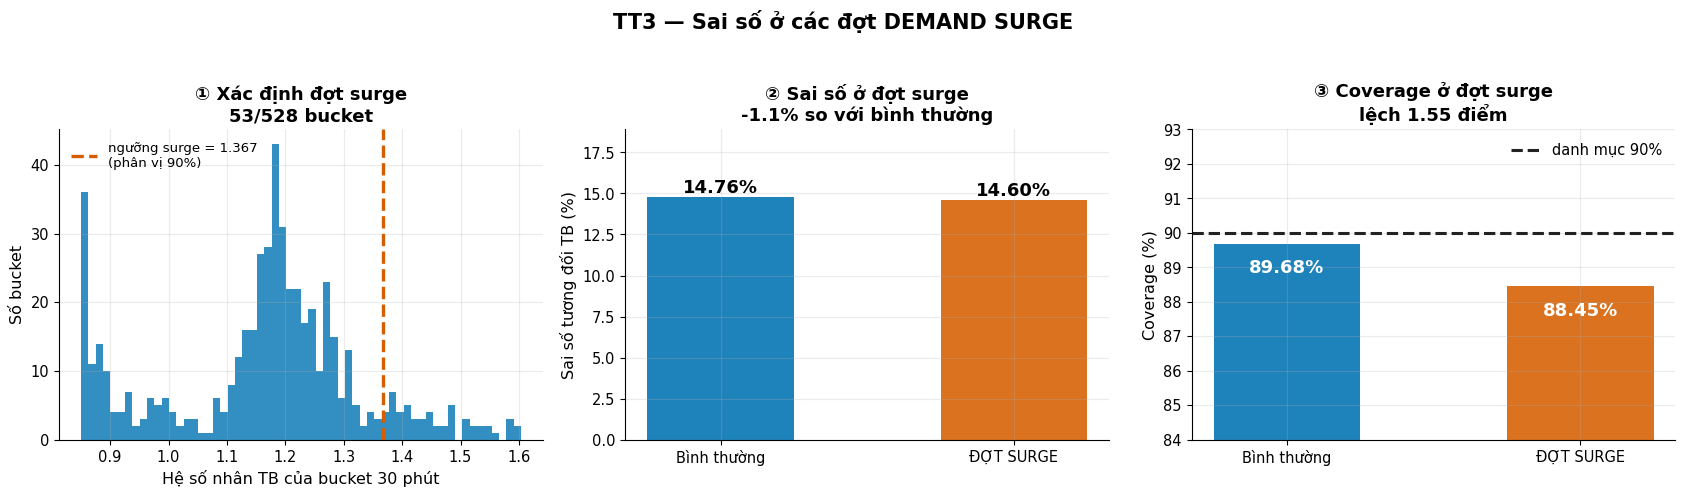

Nguong surge: he so nhan TB bucket >= 1.3666
                          n   sai so rel   coverage
----------------------------------------------------
  Binh thuong       772,740      14.76%     89.68%
  DOT SURGE          91,620      14.60%     88.45%


In [4]:
# ═════════ HINH TT3 — demand surge ═════════
t["buc"] = t.target_timestamp.dt.floor("30min")
gb = t.groupby("buc").agg(
    heso=("heso_that", "mean"), sai=("sai_rel", "mean"),
    cvg=("trong", "mean"), gia=("gia_that", "mean"), n=("gia_that", "size"))
gb = gb[gb.n >= 100]
nguong = gb.heso.quantile(.90)
gb["surge"] = gb.heso >= nguong

# gan nhan surge nguoc ve tung chuyen
t["surge"] = t.buc.map(gb.surge).fillna(False)

fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))

# ① Phan bo he so nhan theo bucket
ax[0].hist(gb.heso, bins=60, color=BLUE, alpha=.8, lw=0)
ax[0].axvline(nguong, color=RED, lw=2.4, ls="--",
              label=f"ngưỡng surge = {nguong:.3f}\n(phân vị 90%)")
ax[0].set_xlabel("Hệ số nhân TB của bucket 30 phút")
ax[0].set_ylabel("Số bucket"); ax[0].legend(frameon=False, fontsize=9.5)
ax[0].set_title(f"① Xác định đợt surge\n{gb.surge.sum()}/{len(gb)} bucket",
                fontweight="bold")

# ② Sai so: surge vs binh thuong
ss = t.groupby("surge").agg(n=("gia_that", "size"), sai=("sai_rel", "mean"),
                            cvg=("trong", "mean"))
x = ["Bình thường", "ĐỢT SURGE"]
b = ax[1].bar(x, ss.sai*100, color=[BLUE, RED], alpha=.88, width=.5)
for bb, v in zip(b, ss.sai*100):
    ax[1].text(bb.get_x()+bb.get_width()/2, v+.25, f"{v:.2f}%", ha="center",
               fontsize=13, fontweight="bold")
ax[1].set_ylabel("Sai số tương đối TB (%)")
ax[1].set_ylim(0, ss.sai.max()*100*1.28)
ch = (ss.sai.iloc[1]/ss.sai.iloc[0]-1)*100
ax[1].set_title(f"② Sai số ở đợt surge\n{ch:+.1f}% so với bình thường",
                fontweight="bold")

# ③ Coverage: surge vs binh thuong
b2 = ax[2].bar(x, ss["cvg"]*100, color=[BLUE, RED], alpha=.88, width=.5)
ax[2].axhline(MUC*100, color=INK, lw=2.2, ls="--", label="danh mục 90%")
# dat nhan BEN TRONG cot: cot 89,71% sat duong 90% nen nhan o tren se de len
for bb, v in zip(b2, ss["cvg"]*100):
    ax[2].text(bb.get_x()+bb.get_width()/2, v-.45, f"{v:.2f}%", ha="center",
               va="top", fontsize=13, fontweight="bold", color="white")
ax[2].set_ylabel("Coverage (%)"); ax[2].set_ylim(84, 93)
ax[2].legend(frameon=False)
lech_sg = abs(ss["cvg"].iloc[1] - .9) * 100
ax[2].set_title(f"③ Coverage ở đợt surge\nlệch {lech_sg:.2f} điểm",
                fontweight="bold")

fig.suptitle("TT3 — Sai số ở các đợt DEMAND SURGE", fontweight="bold",
             fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "TT3_demand_surge.png"); plt.show()

print(f"Nguong surge: he so nhan TB bucket >= {nguong:.4f}")
print(f"{'':16s} {'n':>10s} {'sai so rel':>12s} {'coverage':>10s}")
print("-" * 52)
for k, r in ss.iterrows():
    r_cvg = r["cvg"]
    print(f"  {'DOT SURGE' if k else 'Binh thuong':14s} {int(r.n):>10,} "
          f"{r.sai:>11.2%} {r_cvg:>10.2%}")

## 4. Model mình thuộc kịch bản nào?

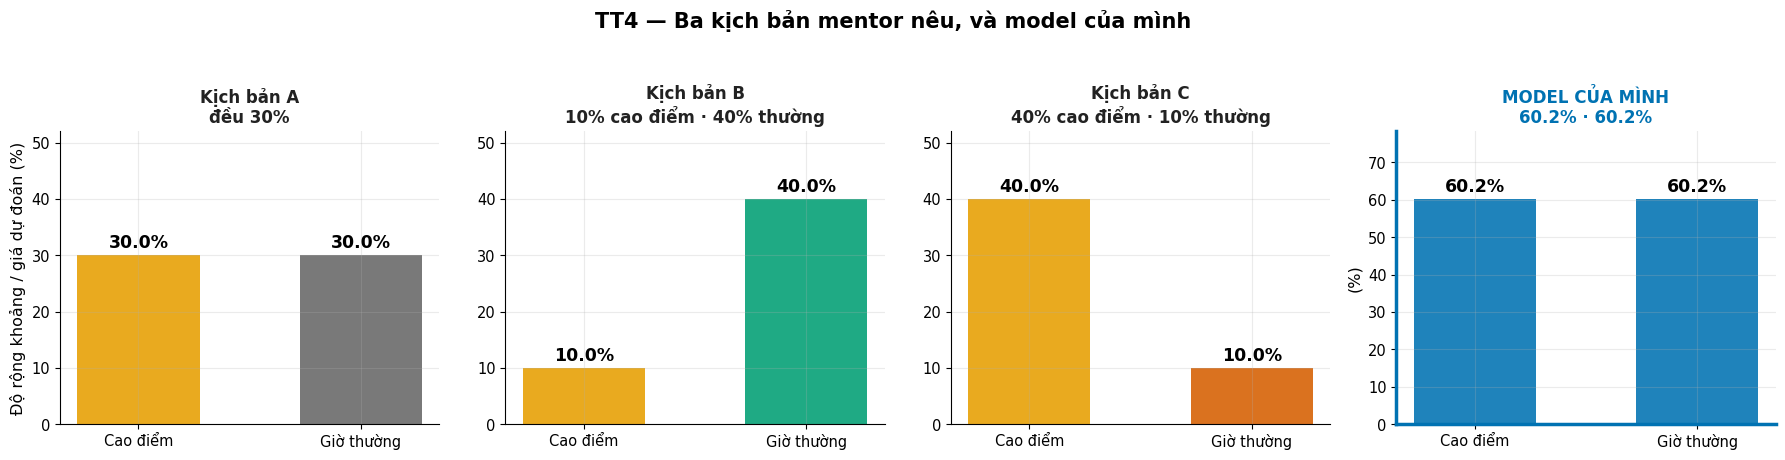

MODEL CUA MINH:
  Do rong khoang  : cao diem 60.18% | gio thuong 60.18%  -> chenh 0.00%
  Sai so thuc te  : cao diem 14.74% | gio thuong 14.75%  -> chenh 0.02%

=> Thuoc KICH BAN A — uncertainty gan nhu DEU o moi khung gio.


In [5]:
# ═════════ HINH TT4 — ba kich ban cua mentor ═════════
sai_cd = t[t.cao_diem].sai_rel.mean()
sai_th = t[~t.cao_diem].sai_rel.mean()
rong_cd = (t[t.cao_diem].hi - t[t.cao_diem].lo).mean() / t[t.cao_diem].hybrid_pred.mean()
rong_th = (t[~t.cao_diem].hi - t[~t.cao_diem].lo).mean() / t[~t.cao_diem].hybrid_pred.mean()

# khong sharey: model that rong 60% > moc 40% cua ba kich ban gia dinh,
# dung chung truc se cat cut cot cuoi
fig, ax = plt.subplots(1, 4, figsize=(18, 4.4))
KB = [("Kịch bản A\nđều 30%", 30, 30, MUT),
      ("Kịch bản B\n10% cao điểm · 40% thường", 10, 40, GREEN),
      ("Kịch bản C\n40% cao điểm · 10% thường", 40, 10, RED),
      (f"MODEL CỦA MÌNH\n{rong_cd*100:.1f}% · {rong_th*100:.1f}%",
       rong_cd*100, rong_th*100, BLUE)]
for k, (ten, v_cd, v_th, col) in enumerate(KB):
    b = ax[k].bar(["Cao điểm", "Giờ thường"], [v_cd, v_th],
                  color=[ORANGE, col] if k < 3 else [BLUE, BLUE],
                  alpha=.88, width=.55)
    tran = 52 if k < 3 else max(v_cd, v_th) * 1.30
    for bb, v in zip(b, [v_cd, v_th]):
        ax[k].text(bb.get_x()+bb.get_width()/2, v + tran*.025, f"{v:.1f}%",
                   ha="center", fontsize=12.5, fontweight="bold")
    ax[k].set_ylim(0, tran)
    ax[k].set_ylabel("(%)" if k == 3 else "")
    ax[k].set_title(ten, fontweight="bold", fontsize=12,
                    color=INK if k < 3 else BLUE)
    if k == 3:
        for sp in ax[k].spines.values():
            sp.set_edgecolor(BLUE); sp.set_linewidth(2.5)
ax[0].set_ylabel("Độ rộng khoảng / giá dự đoán (%)")
fig.suptitle("TT4 — Ba kịch bản mentor nêu, và model của mình",
             fontweight="bold", fontsize=15, y=1.04)
plt.tight_layout(); plt.savefig(HINH / "TT4_ba_kich_ban.png"); plt.show()

print("MODEL CUA MINH:")
print(f"  Do rong khoang  : cao diem {rong_cd:.2%} | gio thuong {rong_th:.2%}  "
      f"-> chenh {abs(rong_cd/rong_th-1)*100:.2f}%")
print(f"  Sai so thuc te  : cao diem {sai_cd:.2%} | gio thuong {sai_th:.2%}  "
      f"-> chenh {abs(sai_cd/sai_th-1)*100:.2f}%")
print()
print("=> Thuoc KICH BAN A — uncertainty gan nhu DEU o moi khung gio.")

## Kết luận

In [6]:
print("╔" + "═"*74 + "╗")
print("║" + " SAI SO THEO THOI GIAN — KET LUAN ".center(74) + "║")
print("╚" + "═"*74 + "╝")
print()
print("  1. MODEL THUOC KICH BAN A — uncertainty DEU")
print(f"     Sai so tuong doi: cao diem {sai_cd:.2%} vs gio thuong {sai_th:.2%}")
print(f"     Coverage        : cao diem {t[t.cao_diem].trong.mean():.2%} vs "
      f"gio thuong {t[~t.cao_diem].trong.mean():.2%}")
print(f"     Bien do sai so qua 24 gio: chi {bd:.1f}%")
print()
print("  2. MAE TUYET DOI co chenh — nhung KHONG phai model kem di")
print(f"     MAE: {gh.mae.min():,.0f}d (gio {gh.mae.idxmin()}h) -> "
      f"{gh.mae.max():,.0f}d (gio {gh.mae.idxmax()}h) = {bd2:.0f}%")
print(f"     Ly do: GIA cao hon, khong phai sai so tuong doi cao hon.")
print()
print("  3. DOT DEMAND SURGE cung khong lam model te di")
print(f"     Sai so: {ss.sai.iloc[0]:.2%} (binh thuong) -> {ss.sai.iloc[1]:.2%} (surge) "
      f"= {ch:+.1f}%")
cov_bt, cov_sg = ss["cvg"].iloc[0], ss["cvg"].iloc[1]
print(f"     Coverage: {cov_bt:.2%} -> {cov_sg:.2%}")
print()
print("─"*76)
print("  => Model KHONG fail o thoi diem nhay cam. No fail o BAND GIA CAO.")
print("     Xem notebook 07: band >300k coverage chi 82,72%.")
print("─"*76)

╔══════════════════════════════════════════════════════════════════════════╗
║                     SAI SO THEO THOI GIAN — KET LUAN                     ║
╚══════════════════════════════════════════════════════════════════════════╝

  1. MODEL THUOC KICH BAN A — uncertainty DEU
     Sai so tuong doi: cao diem 14.74% vs gio thuong 14.75%
     Coverage        : cao diem 89.61% vs gio thuong 89.53%
     Bien do sai so qua 24 gio: chi 3.8%

  2. MAE TUYET DOI co chenh — nhung KHONG phai model kem di
     MAE: 12,655d (gio 3h) -> 21,186d (gio 18h) = 67%
     Ly do: GIA cao hon, khong phai sai so tuong doi cao hon.

  3. DOT DEMAND SURGE cung khong lam model te di
     Sai so: 14.76% (binh thuong) -> 14.60% (surge) = -1.1%
     Coverage: 89.68% -> 88.45%

────────────────────────────────────────────────────────────────────────────
  => Model KHONG fail o thoi diem nhay cam. No fail o BAND GIA CAO.
     Xem notebook 07: band >300k coverage chi 82,72%.
──────────────────────────────────────────